In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


In [3]:
df=pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [5]:
df.columns.tolist()

['Id',
 'SepalLengthCm',
 'SepalWidthCm',
 'PetalLengthCm',
 'PetalWidthCm',
 'Species']

In [8]:
X = df[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]]
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [9]:
Y=df['Species']
Y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object

In [10]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=45)

In [13]:
mymodel=DecisionTreeClassifier()
mymodel.fit(x_train,y_train)

DecisionTreeClassifier()

In [14]:
prediction=mymodel.predict(x_test)
print(y_test)
print(prediction.tolist())

0          Iris-setosa
43         Iris-setosa
129     Iris-virginica
3          Iris-setosa
34         Iris-setosa
44         Iris-setosa
38         Iris-setosa
105     Iris-virginica
123     Iris-virginica
140     Iris-virginica
28         Iris-setosa
125     Iris-virginica
113     Iris-virginica
103     Iris-virginica
133     Iris-virginica
35         Iris-setosa
145     Iris-virginica
142     Iris-virginica
40         Iris-setosa
87     Iris-versicolor
84     Iris-versicolor
85     Iris-versicolor
115     Iris-virginica
51     Iris-versicolor
4          Iris-setosa
112     Iris-virginica
92     Iris-versicolor
64     Iris-versicolor
10         Iris-setosa
91     Iris-versicolor
Name: Species, dtype: object
['Iris-setosa', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-virginica', 'Iris-virginica', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica', 'Iris-virginica', 'Iris-virginica', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica'

In [15]:
acc=accuracy_score(y_test,prediction)
print(acc*100)


100.0


**GRAPHS**

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

*SCATTER PLOT-RELATION BETWEEN PETAL LENGTH AND PETAL WIDHTH*

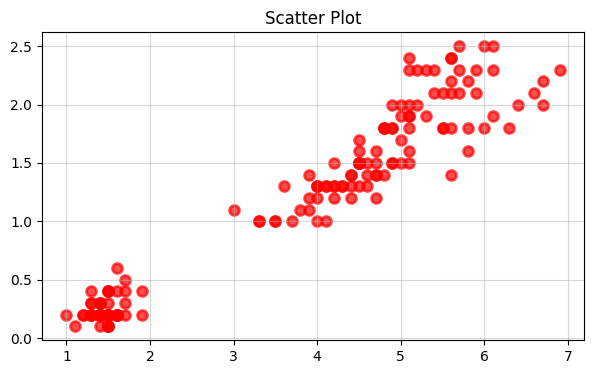

In [20]:
plt.figure(figsize=(7,4),facecolor="white")
plt.scatter(df["PetalLengthCm"],df["PetalWidthCm"],s=50,c="red",marker="o",lw=2,alpha=0.7)
plt.title("Scatter Plot")
plt.grid(True,alpha=0.5)
plt.show()

**HISTOGRAM**

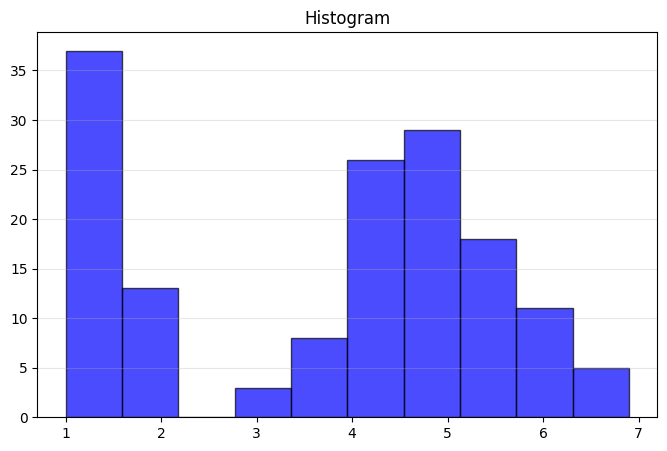

In [21]:
plt.figure(figsize=(8,5),facecolor="white")
plt.hist(df["PetalLengthCm"],bins=10,color="blue",edgecolor="black",lw=2,alpha=0.7)
plt.title("Histogram")
plt.grid(axis='y',alpha=0.3)
plt.show()

**KDE PLOT**

In [23]:
import seaborn as sns

/tmp/ipykernel_58/162025442.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


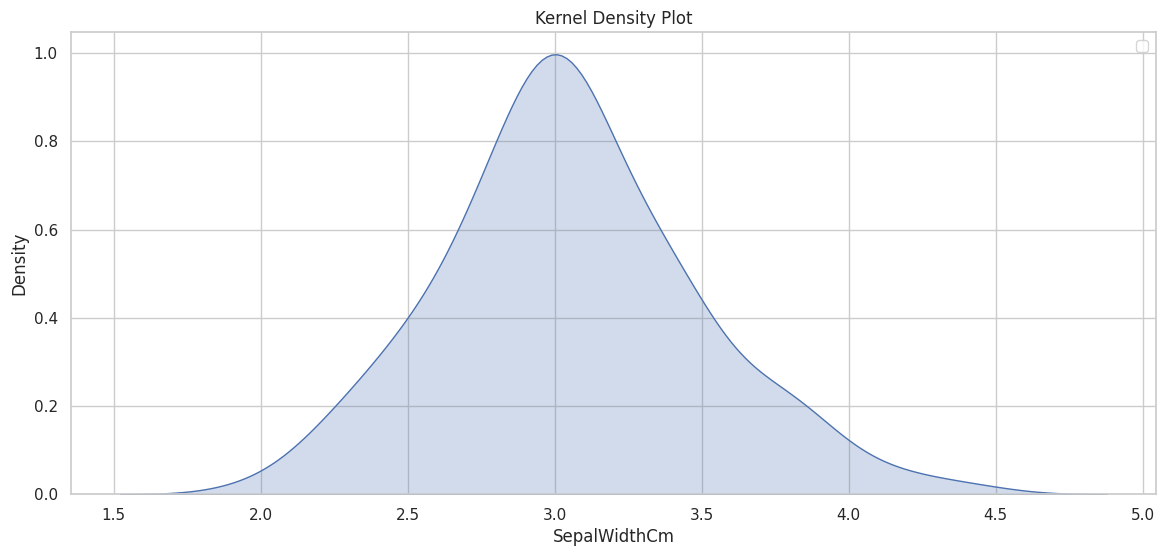

In [24]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14,6))
sns.kdeplot(df["SepalWidthCm"],fill=True)
plt.title("Kernel Density Plot")
plt.legend()
plt.show()

**BOX PLOT**

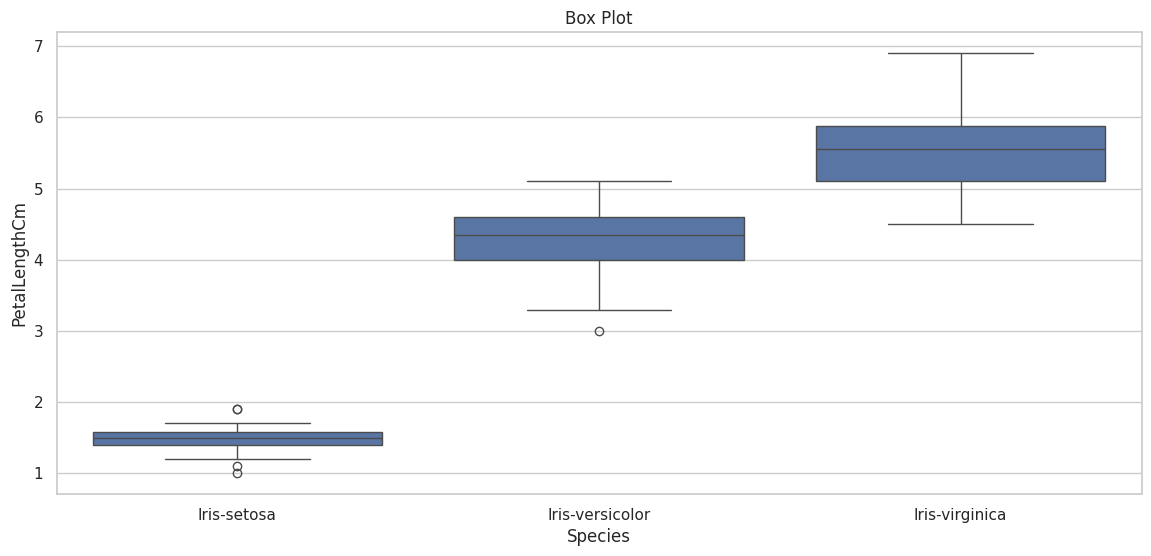

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14,6))
sns.boxplot(x="Species",y="PetalLengthCm",data=df)
plt.xlabel("Species")
plt.ylabel("PetalLengthCm")
plt.title("Box Plot")
plt.show()

**BAR PLOT**

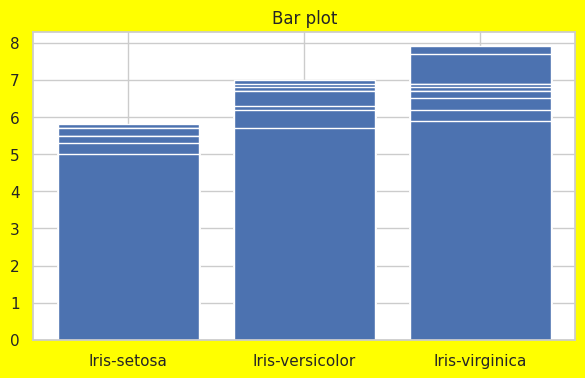

In [26]:
plt.figure(figsize=(7,4),facecolor="yellow") 
plt.bar(df["Species"],df["SepalLengthCm"])
plt.title("Bar plot")
plt.show()